# 06 · Ingeniería de variables y optimización con Optuna

Amplía el dataset del notebook 01 con seis bloques de variables nuevas (todas con corte en t-1), entrena XGBoost y CatBoost sobre la misma partición 80/10/10 del 04 con búsqueda bayesiana de hiperparámetros (Optuna), mide el aporte de las variables nuevas, comprueba en validación temporal (diciembre) y genera el archivo de Kaggle. Todo queda en MLflow.

1. Carga · 2. Variables nuevas (A a F) · 3. Guardado · 4. Partición · 5. XGBoost con Optuna · 6. Aporte de las variables nuevas · 7. CatBoost con Optuna · 8. Comparación en X_test · 9. Validación temporal · 10. Modelo final y Kaggle

In [1]:
import warnings, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import xgboost as xgb
import optuna
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, precision_recall_curve, average_precision_score

warnings.filterwarnings("ignore"); optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.width", 200, "display.max_columns", 60)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"; PROC = DATA / "processed"; OUT = ROOT / "outputs"; OUT.mkdir(exist_ok=True); (ROOT / "models").mkdir(exist_ok=True)
C_BLUE, C_ORANGE, C_AQUA, C_GRAY, C_MUTED = "#2a78d6", "#eb6834", "#1baf7a", "#c9c8c3", "#52514e"
mpl.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": C_GRAY, "axes.grid": True, "grid.color": "#ececea",
                     "axes.axisbelow": True, "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.labelcolor": C_MUTED, "xtick.color": C_MUTED, "ytick.color": C_MUTED})
SEED = 42; N_MESES = 13
import sys; sys.path.insert(0, str(ROOT / "src"))
from tracking import grupo, registrar_busqueda, registrar_final, anexar, resumen
import mlflow
TAGS = {"notebook": "06_feature_engineering", "validacion": "aleatoria_80_10_10", "particion": "estratificada seed 42", "busqueda": "optuna_tpe"}

def month_idx(yyyymm): return (yyyymm // 100 - 2023) * 12 + (yyyymm % 100 - 1)

## 1. Carga

Dataset procesado (133 variables, train y test), lista de 77 seleccionadas, y las tablas crudas de pagos, probabilidades y trtest para construir las variables nuevas.

In [2]:
train = pd.read_parquet(PROC / "train.parquet"); test = pd.read_parquet(PROC / "test.parquet")
FEATS77 = pd.read_csv(PROC / "features_seleccionadas.csv").feature.tolist()
TARGET = "var_rpta_alt"; ID_COLS = ["nit_enmascarado", "num_oblig_orig_enmascarado", "num_oblig_enmascarado", "fecha_var_rpta_alt", "ID", "t", "t_1"]
FEATS133 = [c for c in train.columns if c not in ID_COLS + [TARGET]]
base = pd.concat([train[ID_COLS], test[ID_COLS]], ignore_index=True)
n_tr = len(train); t_arr = base.t.to_numpy()

pag = pd.read_csv(DATA / "prueba_op_maestra_cuotas_pagos_mes_hist_enmascarado_completa.csv", low_memory=False)
pag["t"] = month_idx(pag.fecha_corte // 100); pag = pag.drop_duplicates(["num_oblig_enmascarado", "t"])
pag["porc_pago"] = pag.porc_pago.replace([np.inf, -np.inf], np.nan).clip(upper=500)
pag["pago_flag"] = (pag.pago_total > 0).astype(float); pag["pago_completo"] = (pag.porc_pago >= 100).astype(float); pag["rediferido"] = (pag.ajustes_banco == "REDIFERIDOS").astype(float)
prob = pd.read_csv(DATA / "prueba_op_probabilidad_oblig_base_hist_enmascarado_completa.csv"); prob["t"] = month_idx(prob.fecha_corte); prob = prob.drop_duplicates(["num_oblig_enmascarado", "t"])
tr_raw = pd.read_csv(DATA / "prueba_op_base_pivot_var_rpta_alt_enmascarado_trtest.csv", low_memory=False); tr_raw["t"] = month_idx(tr_raw.fecha_var_rpta_alt)
print(f"base: {len(base):,} filas ({n_tr:,} train + {len(test):,} test) | pagos {len(pag):,} | prob {len(prob):,} | trtest {len(tr_raw):,}")

base: 680,800 filas (568,251 train + 112,549 test) | pagos 4,855,007 | prob 4,804,833 | trtest 568,251


In [3]:
def to_wide(df, idx, col_t, values, n_rows):
    M = np.full((n_rows, N_MESES), np.nan); M[idx, col_t] = values; return M

def ventana(M, r, t, k):
    "Matriz (n, k) con M[r, t-k .. t-1]; NaN donde no hay fila o el mes es negativo."
    cols = t[:, None] - k + np.arange(k)[None, :]
    ok = (cols >= 0) & (r[:, None] >= 0)
    W = np.full(cols.shape, np.nan); rr = np.clip(r, 0, None)[:, None] * np.ones_like(cols); W[ok] = M[rr[ok], cols[ok]]; return W

def pendiente(W):
    "Pendiente de mínimos cuadrados por fila ignorando NaN (x = 0..k-1)."
    k = W.shape[1]; x = np.arange(k, dtype=float)[None, :]; m = ~np.isnan(W); n = m.sum(1)
    Wz = np.nan_to_num(W); sx = (x * m).sum(1); sy = Wz.sum(1); sxy = (x * Wz).sum(1); sxx = (x * x * m).sum(1)
    den = n * sxx - sx ** 2
    with np.errstate(invalid="ignore", divide="ignore"): s = (n * sxy - sx * sy) / den
    s[(n < 3) | (den == 0)] = np.nan; return s

def racha_final(W):
    "Meses consecutivos con valor 0 al final de la ventana (NaN corta la racha)."
    Z = np.where(np.isnan(W), 0, (W == 0).astype(int)); out = np.zeros(len(W)); vivo = np.ones(len(W), bool)
    for j in range(W.shape[1] - 1, -1, -1):
        vivo &= Z[:, j] == 1; out += vivo
    return out

def racha_max(W):
    Z = np.where(np.isnan(W), 0, (W == 0).astype(int)); cur = np.zeros(len(W)); mx = np.zeros(len(W))
    for j in range(W.shape[1]):
        cur = (cur + 1) * Z[:, j]; mx = np.maximum(mx, cur)
    return mx

def meses_desde(M_flag, r, t):
    "Meses desde el último mes (< t) con flag == 1."
    idx = np.where(M_flag == 1, np.arange(N_MESES)[None, :], np.nan); L = pd.DataFrame(idx).ffill(axis=1).to_numpy()
    out = t - L[np.clip(r, 0, None), t - 1]; out[r < 0] = np.nan; return out

nuevas = pd.DataFrame(index=base.index)

## 2. Variables nuevas

Seis bloques, todos con información hasta t-1. Prefijo `fe_`.

**A. Tendencia y ritmo de pago** (pagos): pendiente del % de pago y del pago total en 6 meses, racha actual y máxima de meses sin pago en 12, meses desde el último pago completo y desde el último rediferido, cambio de cuota t-1 frente a t-6.

In [4]:
oi = pd.Index(pag.num_oblig_enmascarado.unique()); rp = oi.get_indexer(pag.num_oblig_enmascarado); r = oi.get_indexer(base.num_oblig_enmascarado)
M = {v: to_wide(pag, rp, pag.t.to_numpy(), pag[v].to_numpy(), len(oi)) for v in ["porc_pago", "pago_total", "pago_flag", "pago_completo", "rediferido", "valor_cuota_mes"]}
W6 = ventana(M["porc_pago"], r, t_arr, 6); nuevas["fe_pend_porc_pago_6m"] = pendiente(W6)
nuevas["fe_pend_pago_total_6m"] = pendiente(np.log1p(np.clip(ventana(M["pago_total"], r, t_arr, 6), 0, None)))
W12 = ventana(M["pago_flag"], r, t_arr, 12); nuevas["fe_racha_sin_pago_actual"] = racha_final(W12); nuevas["fe_racha_sin_pago_max12"] = racha_max(W12)
nuevas["fe_meses_desde_pago_completo"] = meses_desde(M["pago_completo"], r, t_arr); nuevas["fe_meses_desde_rediferido"] = meses_desde(M["rediferido"], r, t_arr)
Wc = ventana(M["valor_cuota_mes"], r, t_arr, 6)
with np.errstate(invalid="ignore", divide="ignore"): nuevas["fe_cuota_ratio_t1_t6"] = Wc[:, -1] / np.where(Wc[:, 0] > 0, Wc[:, 0], np.nan)
print("A listo:", [c for c in nuevas.columns]); nuevas.describe().T[["count", "mean", "50%", "max"]].round(3)

A listo: ['fe_pend_porc_pago_6m', 'fe_pend_pago_total_6m', 'fe_racha_sin_pago_actual', 'fe_racha_sin_pago_max12', 'fe_meses_desde_pago_completo', 'fe_meses_desde_rediferido', 'fe_cuota_ratio_t1_t6']


,count,mean,50%,max
fe_pend_porc_pago_6m,657322.0,-10.171,-7.800,250.000
fe_pend_pago_total_6m,665715.0,-0.263,-0.132,9.673
fe_racha_sin_pago_actual,680800.0,1.021,0.000,12.000
fe_racha_sin_pago_max12,680800.0,1.750,1.000,12.000
fe_meses_desde_pago_completo,624813.0,2.388,2.000,12.000
fe_meses_desde_rediferido,88320.0,4.874,4.000,12.000
fe_cuota_ratio_t1_t6,577154.0,6.152,1.012,444737.000


**B. Trayectoria de los scores del banco** (probabilidades): pendiente de 6 meses de los tres scores, si la alerta temprana superó 0,5 en los últimos 3 meses, cambio de lote entre t-3 y t-1.

In [5]:
oi2 = pd.Index(prob.num_oblig_enmascarado.unique()); rp2 = oi2.get_indexer(prob.num_oblig_enmascarado); r2 = oi2.get_indexer(base.num_oblig_enmascarado)
for v in ["prob_propension", "prob_alrt_temprana", "prob_auto_cura"]:
    Mv = to_wide(prob, rp2, prob.t.to_numpy(), prob[v].to_numpy(), len(oi2)); nuevas[f"fe_pend_{v}_6m"] = pendiente(ventana(Mv, r2, t_arr, 6))
    if v == "prob_alrt_temprana": nuevas["fe_alerta_sobre_05_3m"] = (np.nanmax(ventana(Mv, r2, t_arr, 3), axis=1) >= 0.5).astype(float)
Ml = to_wide(prob, rp2, prob.t.to_numpy(), prob["lote"].to_numpy().astype(float), len(oi2)); Wl = ventana(Ml, r2, t_arr, 3)
nuevas["fe_lote_cambio_3m"] = Wl[:, -1] - Wl[:, 0]
print("B listo")

B listo


**C. Contexto de la obligación dentro del cliente** (pagos): peso de la cuota de esta obligación en la cuota total del cliente, proporción de obligaciones del cliente sin pago en t-1, y si alguna obligación del cliente tuvo rediferido en 12 meses.

In [6]:
todo = pd.concat([train, test], ignore_index=True)
with np.errstate(invalid="ignore", divide="ignore"):
    nuevas["fe_cuota_share_cliente"] = (todo["pag_cuota_mean_1m"] / todo["pagcli_cuota_total_t1"].replace(0, np.nan)).clip(upper=1).to_numpy()
    nuevas["fe_share_oblig_sin_pago"] = (todo["pagcli_n_no_pago_t1"] / todo["pagcli_n_oblig_t1"].replace(0, np.nan)).to_numpy()
cli_m = pag.groupby(["nit_enmascarado", "t"]).rediferido.max().reset_index()
ni = pd.Index(cli_m.nit_enmascarado.unique()); Mr = to_wide(cli_m, ni.get_indexer(cli_m.nit_enmascarado), cli_m.t.to_numpy(), cli_m.rediferido.to_numpy(), len(ni))
nuevas["fe_cliente_rediferido_12m"] = (np.nansum(ventana(Mr, ni.get_indexer(base.nit_enmascarado), t_arr, 12), axis=1) > 0).astype(float)
print("C listo")

C listo


**D. Tasas históricas de aceptación por grupo** (trtest, solo meses anteriores a t): por producto, aplicativo y segmento de la obligación. Para agosto no existen (no hay meses previos); para el test usan los cinco meses.

In [7]:
def tasa_historica(col_tr, col_base, normalizar=False):
    k_tr = tr_raw[col_tr].astype(str); k_b = todo[col_base].astype(str)
    if normalizar: k_tr = k_tr.str.upper().str.strip(); k_b = k_b.str.upper().str.strip()
    cats = pd.Index(sorted(set(k_tr.unique())))
    g = tr_raw.assign(k=k_tr).groupby(["k", "t"])[TARGET].agg(["sum", "size"]).reset_index()
    Sy = to_wide(g, cats.get_indexer(g.k), g.t.to_numpy(), g["sum"].to_numpy().astype(float), len(cats)); Sn = to_wide(g, cats.get_indexer(g.k), g.t.to_numpy(), g["size"].to_numpy().astype(float), len(cats))
    cy = np.nancumsum(np.nan_to_num(Sy), axis=1); cn = np.nancumsum(np.nan_to_num(Sn), axis=1)
    rb = cats.get_indexer(k_b); ok = rb >= 0
    y_ = np.where(ok, cy[np.clip(rb, 0, None), t_arr - 1], np.nan); n_ = np.where(ok, cn[np.clip(rb, 0, None), t_arr - 1], np.nan)
    with np.errstate(invalid="ignore", divide="ignore"): out = np.where(n_ >= 50, y_ / n_, np.nan)
    return out
nuevas["fe_tasa_hist_producto"] = tasa_historica("producto", "obl_producto")
nuevas["fe_tasa_hist_aplicativo"] = tasa_historica("aplicativo", "obl_aplicativo")
nuevas["fe_tasa_hist_segmento"] = tasa_historica("segmento", "obl_segmento", normalizar=True)
print("D listo | cobertura por mes:"); print(pd.DataFrame({"mes": base.fecha_var_rpta_alt, "ok": nuevas.fe_tasa_hist_producto.notna()}).groupby("mes").ok.mean().round(3).to_dict())

D listo | cobertura por mes:
{202308: 0.0, 202309: 0.998, 202310: 0.998, 202311: 0.998, 202312: 0.998, 202401: 0.998}


**E. Historial del cliente** (trtest, meses anteriores a t): meses desde la última aceptación del cliente en cualquier obligación, meses desde la última aplicación de una opción, y bandera de ventana de espera (aplicación hace 3 meses o menos, cuando la regla de negocio impide otra).

In [8]:
cm = tr_raw.assign(aplic=(tr_raw.marca_alt_apli == "SI").astype(float)).groupby(["nit_enmascarado", "t"]).agg(acepto=(TARGET, "max"), aplic=("aplic", "max")).reset_index()
ni2 = pd.Index(cm.nit_enmascarado.unique()); rn = ni2.get_indexer(cm.nit_enmascarado); rb = ni2.get_indexer(base.nit_enmascarado)
nuevas["fe_meses_desde_acepto_cli"] = meses_desde(to_wide(cm, rn, cm.t.to_numpy(), cm.acepto.to_numpy(), len(ni2)), rb, t_arr)
nuevas["fe_meses_desde_aplicacion_cli"] = meses_desde(to_wide(cm, rn, cm.t.to_numpy(), cm.aplic.to_numpy(), len(ni2)), rb, t_arr)
nuevas["fe_en_espera"] = (nuevas.fe_meses_desde_aplicacion_cli <= 3).astype(float)
print("E listo | en espera:", nuevas.fe_en_espera.mean().round(3))

E listo | en espera: 0.11


**F. Interacciones**: propensión de pago del banco frente a impago reciente (score alto con pagos bajos es el perfil típico de quien acepta un alivio), y mora rezagada por número de opciones preaprobadas.

In [9]:
nuevas["fe_propension_x_impago"] = (todo["prob_prob_propension_t1"] * (1 - (todo["pag_porc_pago_mean_3m"].clip(0, 100) / 100))).to_numpy()
nuevas["fe_mora_x_opciones"] = (todo["lag_dias_mora_fin_ult"] * todo["lag_cant_alter_posibles_ult"]).to_numpy()
FE = list(nuevas.columns)
print(f"Variables nuevas: {len(FE)}")
nul = pd.DataFrame({"train": nuevas.iloc[:n_tr].isna().mean(), "test": nuevas.iloc[n_tr:].isna().mean()}).round(3)
nul

Variables nuevas: 23


,train,test
fe_pend_porc_pago_6m,0.032,0.046
fe_pend_pago_total_6m,0.023,0.020
fe_racha_sin_pago_actual,0.000,0.000
fe_racha_sin_pago_max12,0.000,0.000
fe_meses_desde_pago_completo,0.083,0.078
fe_meses_desde_rediferido,0.868,0.881
fe_cuota_ratio_t1_t6,0.154,0.146
fe_pend_prob_propension_6m,0.032,0.037
fe_pend_prob_alrt_temprana_6m,0.032,0.037
fe_alerta_sobre_05_3m,0.000,0.000


## 3. Guardado

Dataset ampliado: 133 originales + nuevas. Se guarda en `data/processed/train_fe.parquet` y `test_fe.parquet`, y la lista 77 + nuevas en `features_fe.csv`.

In [10]:
train_fe = pd.concat([train.reset_index(drop=True), nuevas.iloc[:n_tr].reset_index(drop=True)], axis=1)
test_fe = pd.concat([test.reset_index(drop=True), nuevas.iloc[n_tr:].reset_index(drop=True)], axis=1)
train_fe.to_parquet(PROC / "train_fe.parquet", index=False); test_fe.to_parquet(PROC / "test_fe.parquet", index=False)
FEATS_FE = FEATS77 + FE; pd.Series(FEATS_FE, name="feature").to_csv(PROC / "features_fe.csv", index=False)
print(f"train_fe {train_fe.shape} | test_fe {test_fe.shape} | variables para modelar: {len(FEATS_FE)} (77 + {len(FE)})")

train_fe (568251, 164) | test_fe (112549, 163) | variables para modelar: 100 (77 + 23)


## 4. Partición 80/10/10

Misma semilla y estratificación que en los notebooks 04 y 05.

In [11]:
CAT = [c for c in FEATS133 if str(train_fe[c].dtype) == "category"]
for c in CAT:
    cats = pd.api.types.union_categoricals([train_fe[c], test_fe[c]]).categories
    train_fe[c] = pd.Categorical(train_fe[c], categories=cats); test_fe[c] = pd.Categorical(test_fe[c], categories=cats)
y = train_fe[TARGET]
idx_tr, idx_tmp = train_test_split(np.arange(len(train_fe)), test_size=0.20, stratify=y, random_state=SEED)
idx_va, idx_te = train_test_split(idx_tmp, test_size=0.50, stratify=y.iloc[idx_tmp], random_state=SEED)
def split(cols): return (train_fe.iloc[idx_tr][cols], y.iloc[idx_tr], train_fe.iloc[idx_va][cols], y.iloc[idx_va], train_fe.iloc[idx_te][cols], y.iloc[idx_te])
X_train, y_train, X_val, y_val, X_test, y_test = split(FEATS_FE)
CAT_FE = [c for c in FEATS_FE if c in CAT]
print(f"X_train {len(X_train):,} | X_val {len(X_val):,} | X_test {len(X_test):,} | variables {len(FEATS_FE)} ({len(CAT_FE)} categóricas)")

def mejor_umbral(y_true, p):
    grid = np.arange(0.20, 0.81, 0.01); f1s = [f1_score(y_true, p >= u) for u in grid]; return float(grid[int(np.argmax(f1s))]), float(max(f1s))
def metricas(y_true, p, u):
    pred = (p >= u).astype(int)
    return {"umbral": u, "AUC": roc_auc_score(y_true, p), "F1": f1_score(y_true, pred), "precisión": precision_score(y_true, pred), "recall": recall_score(y_true, pred), "% pred 1": pred.mean()}
def matriz(ax, y_true, pred, titulo):
    cm = confusion_matrix(y_true, pred); ax.imshow(cm, cmap="Blues"); ax.grid(False)
    for i in range(2):
        for j in range(2): ax.text(j, i, f"{cm[i, j]:,}\n({cm[i, j]/cm.sum():.1%})", ha="center", va="center", fontsize=11, color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1]); ax.set_xticklabels(["pred 0", "pred 1"]); ax.set_yticklabels(["real 0", "real 1"]); ax.set_title(titulo)
def para_cat(df):
    d = df.copy()
    for c in CAT_FE: d[c] = d[c].astype(str).replace("nan", "NA")
    return d

X_train 454,600 | X_val 56,825 | X_test 56,826 | variables 100 (15 categóricas)


## 5. XGBoost con Optuna

10 pruebas de optimización bayesiana (TPE). Cada prueba entrena con parada temprana sobre `X_val` (hasta 2.500 árboles) y se puntúa por el F1 en `X_val` con su mejor umbral. Cada prueba queda como un run de búsqueda en MLflow.

In [12]:
def fit_xgb(params, Xtr, ytr, Xva, yva, n_max=2500):
    m = xgb.XGBClassifier(**params, n_estimators=n_max, early_stopping_rounds=80, tree_method="hist", enable_categorical=True, objective="binary:logistic", eval_metric="logloss", random_state=SEED, n_jobs=12)
    m.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False); return m

g_x = grupo("06_xgboost_fe", modelo="xgboost", **TAGS); g_x.__enter__()
res_xgb = []
def objetivo_xgb(trial):
    params = {"max_depth": trial.suggest_int("max_depth", 5, 10), "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.1, log=True),
              "min_child_weight": trial.suggest_int("min_child_weight", 1, 50, log=True), "subsample": trial.suggest_float("subsample", 0.6, 1.0),
              "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0), "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 10, log=True), "gamma": trial.suggest_float("gamma", 0, 2)}
    t0 = time.time(); m = fit_xgb(params, X_train, y_train, X_val, y_val); p = m.predict_proba(X_val)[:, 1]; u, f1 = mejor_umbral(y_val, p)
    r = {**params, "n_arboles": m.best_iteration + 1, "AUC_val": roc_auc_score(y_val, p), "F1_val": f1, "umbral": u, "seg": round(time.time() - t0)}; res_xgb.append(r)
    registrar_busqueda(trial.number + 1, params, {"f1_val": f1, "auc_val": r["AUC_val"], "umbral": u, "n_arboles": r["n_arboles"], "seg": r["seg"]})
    print(f"[{trial.number+1}/10] F1_val {f1:.4f} | AUC {r['AUC_val']:.4f} | árboles {r['n_arboles']} | {r['seg']} s"); return f1
study_x = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED)); study_x.optimize(objetivo_xgb, n_trials=10)
P_XGB = study_x.best_params; res_xgb = pd.DataFrame(res_xgb).sort_values("F1_val", ascending=False).reset_index(drop=True)
print("\nMejor XGBoost:", P_XGB, "| F1_val", round(study_x.best_value, 4))

[1/10] F1_val 0.7504 | AUC 0.8272 | árboles 2487 | 1210 s


[2/10] F1_val 0.7509 | AUC 0.8295 | árboles 1795 | 652 s


[3/10] F1_val 0.7388 | AUC 0.8139 | árboles 2500 | 556 s


[4/10] F1_val 0.7343 | AUC 0.8081 | árboles 2500 | 449 s


[5/10] F1_val 0.7432 | AUC 0.8198 | árboles 2500 | 603 s


[6/10] F1_val 0.7537 | AUC 0.8350 | árboles 2500 | 536 s


[7/10] F1_val 0.7407 | AUC 0.8174 | árboles 2500 | 239 s


[8/10] F1_val 0.7365 | AUC 0.8111 | árboles 2083 | 171 s


[9/10] F1_val 0.7327 | AUC 0.8056 | árboles 2500 | 232 s


[10/10] F1_val 0.7448 | AUC 0.8216 | árboles 2500 | 290 s

Mejor XGBoost: {'max_depth': 9, 'learning_rate': 0.032654713909375875, 'min_child_weight': 1, 'subsample': 0.8736932106048627, 'colsample_bytree': 0.7200762468698007, 'reg_lambda': 0.7206848764305199, 'gamma': 0.9903538202225404} | F1_val 0.7537


In [13]:
xgb_fe = fit_xgb(P_XGB, X_train, y_train, X_val, y_val)
U_XGB, _ = mejor_umbral(y_val, xgb_fe.predict_proba(X_val)[:, 1]); p_test_xgb = xgb_fe.predict_proba(X_test)[:, 1]
MET_XGB = metricas(y_test, p_test_xgb, U_XGB); print("XGBoost (77 + nuevas) en X_test:", {k: round(v, 4) for k, v in MET_XGB.items()})

XGBoost (77 + nuevas) en X_test: {'umbral': 0.37, 'AUC': 0.8383, 'F1': 0.7572, 'precisión': 0.6813, 'recall': 0.8521, '% pred 1': np.float64(0.6003)}


## 6. Aporte de las variables nuevas

Con los mismos hiperparámetros, tres conjuntos de variables: las 77 solas, las 77 + nuevas (el modelo anterior) y las 133 originales + nuevas. Así se separa el efecto de más árboles y mejor búsqueda del efecto de las variables. Además, la importancia de las variables nuevas dentro del modelo.

In [14]:
abl = {"77 + nuevas": MET_XGB}
for nombre, cols in [("77 solas", FEATS77), ("133 + nuevas", FEATS133 + FE)]:
    Xtr, ytr, Xva, yva, Xte, yte = split(cols); m = fit_xgb(P_XGB, Xtr, ytr, Xva, yva); u, f1v = mejor_umbral(yva, m.predict_proba(Xva)[:, 1])
    abl[nombre] = metricas(yte, m.predict_proba(Xte)[:, 1], u); abl[nombre]["F1_val"] = f1v; abl[nombre]["n_vars"] = len(cols)
    registrar_busqueda(90 + len(abl), {"variables": nombre, "n_vars": len(cols), **P_XGB}, {"f1_val": f1v, "f1_test": abl[nombre]["F1"], "auc_test": abl[nombre]["AUC"], "n_arboles": m.best_iteration + 1})
abl["77 + nuevas"]["F1_val"] = study_x.best_value; abl["77 + nuevas"]["n_vars"] = len(FEATS_FE)
abl = pd.DataFrame(abl).T[["n_vars", "F1_val", "F1", "AUC", "precisión", "recall"]].astype(float); abl

,n_vars,F1_val,F1,AUC,precisión,recall
77 + nuevas,100.0,0.753710,0.757232,0.838323,0.681343,0.852146
77 solas,77.0,0.752597,0.755309,0.836543,0.682832,0.844998
133 + nuevas,156.0,0.755312,0.757878,0.839888,0.682083,0.852623


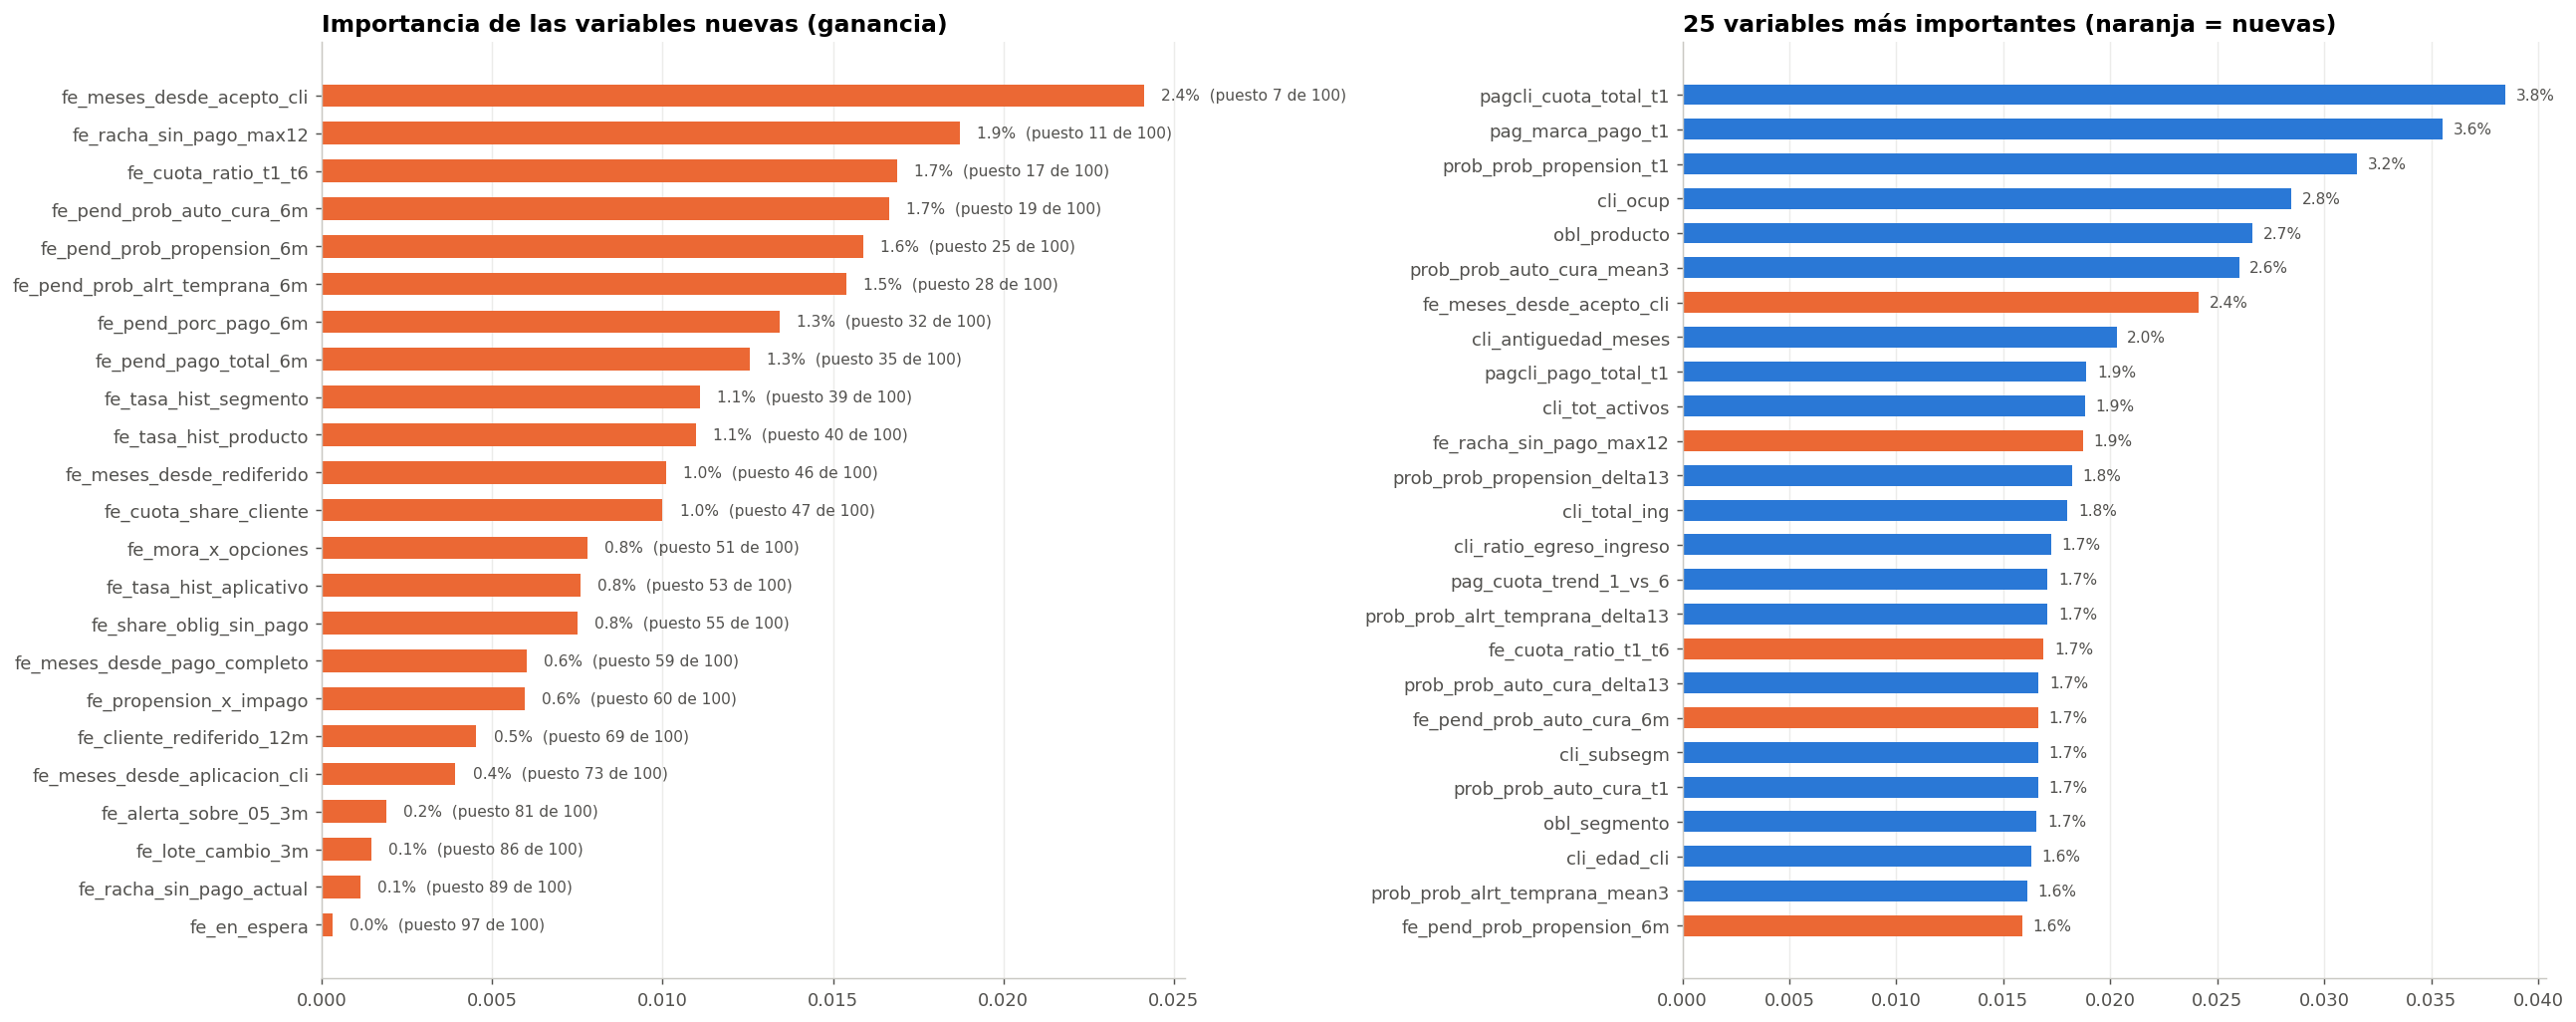

Importancia acumulada de las 23 nuevas: 22.4% | nuevas entre las 25 primeras: 5


In [15]:
imp = pd.Series(xgb_fe.get_booster().get_score(importance_type="total_gain")); imp = (imp / imp.sum()).reindex(FEATS_FE).fillna(0).sort_values(ascending=False)
rank = pd.Series(np.arange(1, len(imp) + 1), index=imp.index)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
d = imp[FE].sort_values().iloc[-len(FE):]
axes[0].barh(d.index, d.values, color=C_ORANGE, height=0.6)
for yv, v in zip(d.index, d.values): axes[0].text(v + 0.0005, yv, f"{v:.1%}  (puesto {rank[yv]} de {len(imp)})", va="center", fontsize=8.5, color=C_MUTED)
axes[0].set_title("Importancia de las variables nuevas (ganancia)"); axes[0].grid(axis="y", visible=False)
d = imp.head(25).iloc[::-1]
axes[1].barh(d.index, d.values, color=[C_ORANGE if c in FE else C_BLUE for c in d.index], height=0.6)
for yv, v in zip(d.index, d.values): axes[1].text(v + 0.0005, yv, f"{v:.1%}", va="center", fontsize=8.5, color=C_MUTED)
axes[1].set_title("25 variables más importantes (naranja = nuevas)"); axes[1].grid(axis="y", visible=False)
plt.tight_layout(); fig_imp = fig; plt.show()
print(f"Importancia acumulada de las {len(FE)} nuevas: {imp[FE].sum():.1%} | nuevas entre las 25 primeras: {sum(c in FE for c in imp.head(25).index)}")

## 7. CatBoost con Optuna

5 pruebas (es de 5 a 8 veces más lento que XGBoost), hasta 1.200 iteraciones con parada temprana sobre `X_val`.

In [16]:
Xc_train, Xc_val, Xc_test = para_cat(X_train), para_cat(X_val), para_cat(X_test)
pool_tr = Pool(Xc_train, y_train, cat_features=CAT_FE); pool_va = Pool(Xc_val, y_val, cat_features=CAT_FE)
def fit_cat(params, ptr, pva, n_max=1200):
    m = CatBoostClassifier(**params, iterations=n_max, od_type="Iter", od_wait=60, loss_function="Logloss", random_seed=SEED, verbose=False, thread_count=12)
    m.fit(ptr, eval_set=pva, use_best_model=True); return m
def met_dict(M, pref): return {f"f1_{pref}": M["F1"], f"auc_{pref}": M["AUC"], f"precision_{pref}": M["precisión"], f"recall_{pref}": M["recall"], f"pct_pred_1_{pref}": M["% pred 1"]}
rid_x = registrar_final(P_XGB, {**met_dict(MET_XGB, "test"), "f1_val": study_x.best_value, "n_arboles": xgb_fe.best_iteration + 1}, U_XGB, FEATS_FE, modelo=xgb_fe, flavor="xgboost")
g_x.__exit__(None, None, None)
g_c = grupo("06_catboost_fe", modelo="catboost", **TAGS); g_c.__enter__()
res_cat = []
def objetivo_cat(trial):
    params = {"depth": trial.suggest_int("depth", 5, 8), "learning_rate": trial.suggest_float("learning_rate", 0.05, 0.15, log=True), "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10, log=True),
              "random_strength": trial.suggest_float("random_strength", 0.5, 3), "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1)}
    t0 = time.time(); m = fit_cat(params, pool_tr, pool_va); p = m.predict_proba(pool_va)[:, 1]; u, f1 = mejor_umbral(y_val, p)
    r = {**params, "n_arboles": m.get_best_iteration() + 1, "AUC_val": roc_auc_score(y_val, p), "F1_val": f1, "umbral": u, "seg": round(time.time() - t0)}; res_cat.append(r)
    registrar_busqueda(trial.number + 1, params, {"f1_val": f1, "auc_val": r["AUC_val"], "umbral": u, "n_arboles": r["n_arboles"], "seg": r["seg"]})
    print(f"[{trial.number+1}/5] F1_val {f1:.4f} | AUC {r['AUC_val']:.4f} | árboles {r['n_arboles']} | {r['seg']} s"); return f1
study_c = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED)); study_c.optimize(objetivo_cat, n_trials=5)
P_CAT = study_c.best_params; res_cat = pd.DataFrame(res_cat).sort_values("F1_val", ascending=False).reset_index(drop=True)
cat_fe = fit_cat(P_CAT, pool_tr, pool_va); U_CAT, _ = mejor_umbral(y_val, cat_fe.predict_proba(pool_va)[:, 1]); p_test_cat = cat_fe.predict_proba(Pool(Xc_test, cat_features=CAT_FE))[:, 1]
MET_CAT = metricas(y_test, p_test_cat, U_CAT)
rid_c = registrar_final(P_CAT, {**met_dict(MET_CAT, "test"), "f1_val": study_c.best_value, "n_arboles": cat_fe.get_best_iteration() + 1}, U_CAT, FEATS_FE, modelo=cat_fe, flavor="catboost")
g_c.__exit__(None, None, None)
print("\nMejor CatBoost:", P_CAT, "| F1_val", round(study_c.best_value, 4)); print("CatBoost (77 + nuevas) en X_test:", {k: round(v, 4) for k, v in MET_CAT.items()})

[1/5] F1_val 0.7356 | AUC 0.8103 | árboles 1200 | 618 s


[2/5] F1_val 0.7226 | AUC 0.7924 | árboles 1200 | 543 s


[3/5] F1_val 0.7312 | AUC 0.8047 | árboles 1200 | 543 s


[4/5] F1_val 0.7255 | AUC 0.7959 | árboles 1200 | 541 s


[5/5] F1_val 0.7325 | AUC 0.8060 | árboles 1200 | 751 s



Mejor CatBoost: {'depth': 6, 'learning_rate': 0.14209408739311125, 'l2_leaf_reg': 5.395030966670228, 'random_strength': 1.9966462104925915, 'bagging_temperature': 0.15601864044243652} | F1_val 0.7356
CatBoost (77 + nuevas) en X_test: {'umbral': 0.37, 'AUC': 0.8116, 'F1': 0.7375, 'precisión': 0.652, 'recall': 0.8487, '% pred 1': np.float64(0.6247)}


## 8. Comparación en X_test

Ambos modelos con el umbral fijado en `X_val`, junto a los resultados del notebook 04 (77 variables, búsqueda aleatoria, tope de 1.500 árboles) sobre la misma partición.

In [17]:
comp = pd.DataFrame({"XGBoost 06 (77+nuevas, Optuna)": MET_XGB, "CatBoost 06 (77+nuevas, Optuna)": MET_CAT,
                     "XGBoost 04 (77, aleatoria)": {"umbral": 0.37, "AUC": 0.8239, "F1": 0.7468, "precisión": 0.6617, "recall": 0.8569, "% pred 1": 0.6215},
                     "CatBoost 04 (77, aleatoria)": {"umbral": 0.38, "AUC": 0.8041, "F1": 0.7333, "precisión": 0.6513, "recall": 0.8391, "% pred 1": 0.6184}}).T
comp["árboles"] = [xgb_fe.best_iteration + 1, cat_fe.get_best_iteration() + 1, 1500, 1500]; comp.round(4)

,umbral,AUC,F1,precisión,recall,% pred 1,F1_val,n_vars,árboles
"XGBoost 06 (77+nuevas, Optuna)",0.37,0.8383,0.7572,0.6813,0.8521,0.6003,0.7537,100.0,2500
"CatBoost 06 (77+nuevas, Optuna)",0.37,0.8116,0.7375,0.6520,0.8487,0.6247,NaN,NaN,1200
"XGBoost 04 (77, aleatoria)",0.37,0.8239,0.7468,0.6617,0.8569,0.6215,NaN,NaN,1500
"CatBoost 04 (77, aleatoria)",0.38,0.8041,0.7333,0.6513,0.8391,0.6184,NaN,NaN,1500


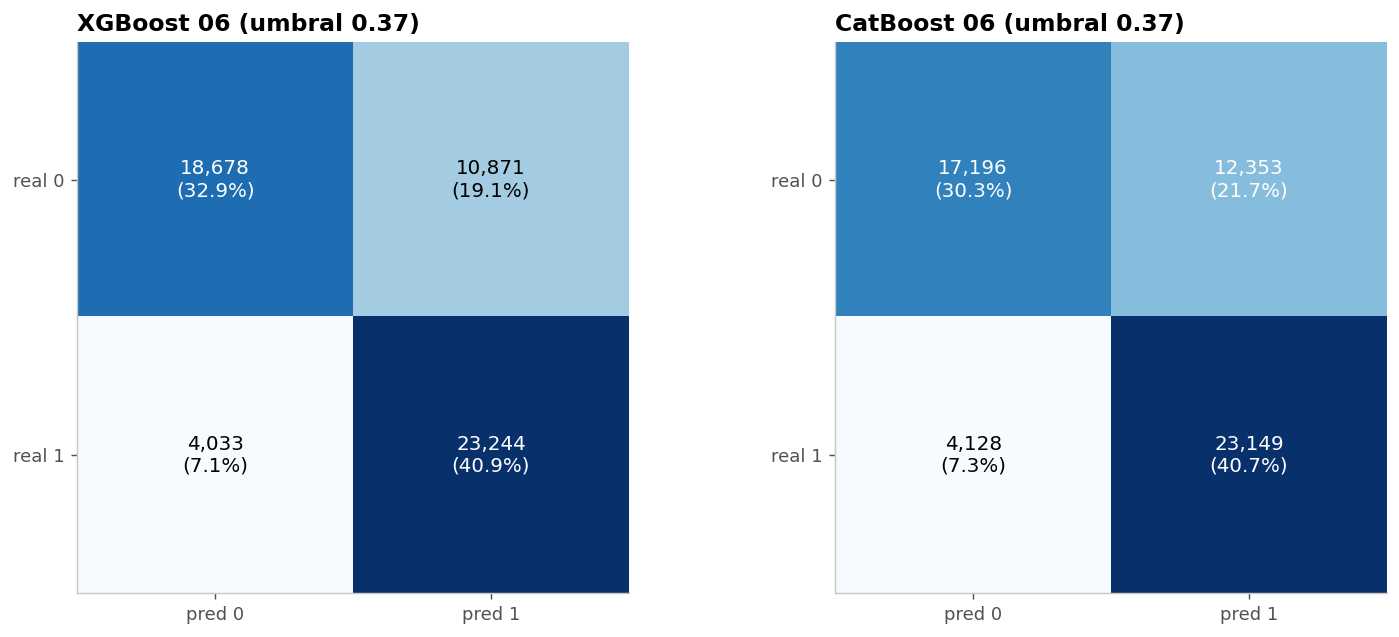

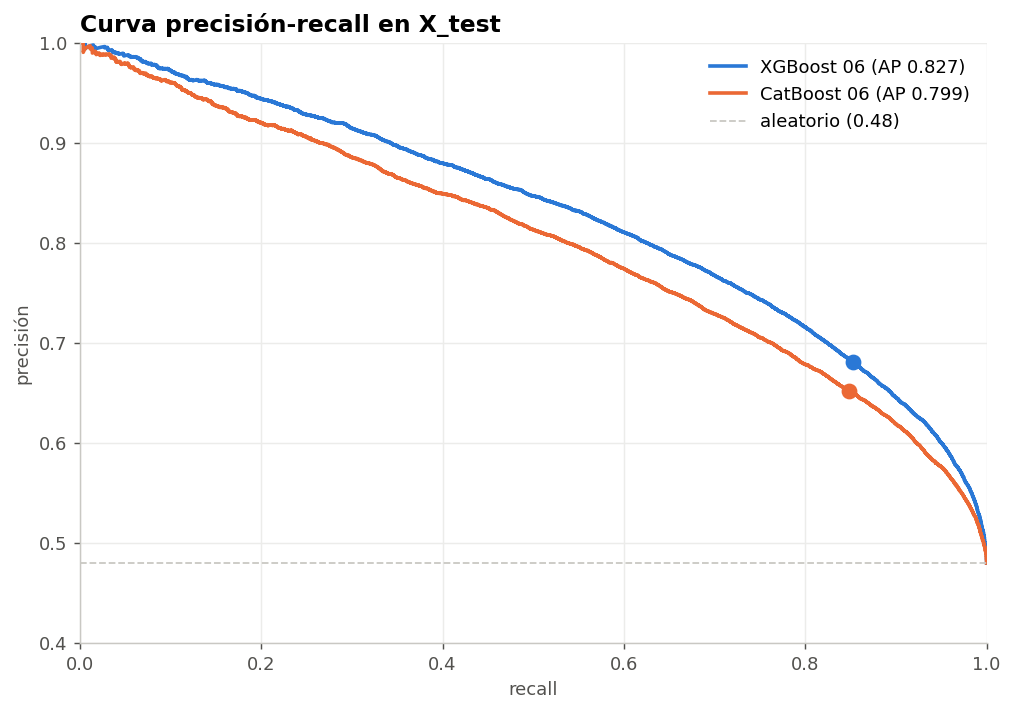

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
matriz(axes[0], y_test, (p_test_xgb >= U_XGB).astype(int), f"XGBoost 06 (umbral {U_XGB:.2f})"); matriz(axes[1], y_test, (p_test_cat >= U_CAT).astype(int), f"CatBoost 06 (umbral {U_CAT:.2f})")
plt.tight_layout(); fig_cm = fig; plt.show()
fig, ax = plt.subplots(figsize=(9, 6))
for nombre, p, u, col in [("XGBoost 06", p_test_xgb, U_XGB, C_BLUE), ("CatBoost 06", p_test_cat, U_CAT, C_ORANGE)]:
    pr, rc, _ = precision_recall_curve(y_test, p); ax.plot(rc, pr, color=col, lw=2, label=f"{nombre} (AP {average_precision_score(y_test, p):.3f})")
    pred = p >= u; ax.scatter([recall_score(y_test, pred)], [precision_score(y_test, pred)], color=col, s=60, zorder=3)
ax.axhline(y_test.mean(), color=C_GRAY, ls="--", lw=1, label=f"aleatorio ({y_test.mean():.2f})"); ax.set_xlabel("recall"); ax.set_ylabel("precisión"); ax.set_xlim(0, 1); ax.set_ylim(0.4, 1); ax.legend(frameon=False); ax.set_title("Curva precisión-recall en X_test")
fig_pr = fig; plt.show()

## 9. Validación temporal

El mejor modelo se reentrena con agosto a noviembre y se mide en diciembre, como en el baseline (F1 0,6931). Es la comprobación que imita el salto a enero.

In [19]:
GANADOR = "XGBoost" if MET_XGB["F1"] >= MET_CAT["F1"] else "CatBoost"
m_tr = train_fe.fecha_var_rpta_alt <= 202311; m_va = train_fe.fecha_var_rpta_alt == 202312
if GANADOR == "XGBoost":
    mt = fit_xgb(P_XGB, train_fe.loc[m_tr, FEATS_FE], y[m_tr], train_fe.loc[m_va, FEATS_FE], y[m_va]); p_dic = mt.predict_proba(train_fe.loc[m_va, FEATS_FE])[:, 1]
else:
    ptr = Pool(para_cat(train_fe.loc[m_tr, FEATS_FE]), y[m_tr], cat_features=CAT_FE); pva = Pool(para_cat(train_fe.loc[m_va, FEATS_FE]), y[m_va], cat_features=CAT_FE)
    mt = fit_cat(P_CAT, ptr, pva); p_dic = mt.predict_proba(pva)[:, 1]
U_DIC, F1_DIC = mejor_umbral(y[m_va], p_dic); MET_DIC = metricas(y[m_va], p_dic, U_DIC)
print(f"{GANADOR} en diciembre (entrenado 08-11): AUC {MET_DIC['AUC']:.4f} | F1 {F1_DIC:.4f} (umbral {U_DIC:.2f}) | baseline LightGBM: F1 0.6931, AUC 0.7589")

XGBoost en diciembre (entrenado 08-11): AUC 0.7649 | F1 0.6964 (umbral 0.35) | baseline LightGBM: F1 0.6931, AUC 0.7589


## 10. Modelo final y archivos para Kaggle

El ganador se reentrena con todas las filas etiquetadas con sus hiperparámetros y número de árboles, califica `oot` con el umbral de `X_val` y escribe `outputs/submission_v3.csv` y `outputs/resultado_prueba_v3.csv`. Al run final del ganador se le anexan las métricas de diciembre, las figuras, el modelo y el submission.

In [20]:
if GANADOR == "XGBoost":
    n_arb = xgb_fe.best_iteration + 1
    final = xgb.XGBClassifier(**P_XGB, n_estimators=n_arb, tree_method="hist", enable_categorical=True, objective="binary:logistic", random_state=SEED, n_jobs=12).fit(train_fe[FEATS_FE], y)
    p_oot = final.predict_proba(test_fe[FEATS_FE])[:, 1]; UMBRAL = U_XGB; final.save_model(str(ROOT / "models" / "xgb_v3.json")); ruta = ROOT / "models" / "xgb_v3.json"; flavor = "xgboost"
else:
    n_arb = cat_fe.get_best_iteration() + 1
    final = CatBoostClassifier(**P_CAT, iterations=n_arb, loss_function="Logloss", random_seed=SEED, verbose=False, thread_count=12).fit(Pool(para_cat(train_fe[FEATS_FE]), y, cat_features=CAT_FE))
    p_oot = final.predict_proba(Pool(para_cat(test_fe[FEATS_FE]), cat_features=CAT_FE))[:, 1]; UMBRAL = U_CAT; final.save_model(str(ROOT / "models" / "catboost_v3.cbm")); ruta = ROOT / "models" / "catboost_v3.cbm"; flavor = "catboost"
ss = pd.read_csv(DATA / "sample_submission.csv", usecols=["ID"])
res = ss.merge(pd.DataFrame({"ID": test_fe.ID.astype(str), "Prob_uno": p_oot}), on="ID", how="left"); res["var_rpta_alt"] = (res.Prob_uno >= UMBRAL).astype(int)
assert res.Prob_uno.notna().all() and len(res) == len(ss)
res[["ID", "var_rpta_alt"]].to_csv(OUT / "submission_v3.csv", index=False); res[["ID", "var_rpta_alt", "Prob_uno"]].round({"Prob_uno": 5}).to_csv(OUT / "resultado_prueba_v3.csv", index=False, encoding="utf-8")
print(f"Ganador: {GANADOR} | árboles {n_arb} | umbral {UMBRAL:.2f} | % predicho 1 en oot: {res.var_rpta_alt.mean():.3f} | prob media {res.Prob_uno.mean():.3f}")

Ganador: XGBoost | árboles 2500 | umbral 0.37 | % predicho 1 en oot: 0.560 | prob media 0.445


In [21]:
figs = {"matrices_confusion": fig_cm, "precision_recall": fig_pr}
anexar(rid_x, tags={"ganador_06": str(GANADOR == "XGBoost")}, figuras={**figs, "importancia": fig_imp})
anexar(rid_c, tags={"ganador_06": str(GANADOR == "CatBoost")}, figuras=figs)
rid_g = rid_x if GANADOR == "XGBoost" else rid_c
anexar(rid_g, metricas={"f1_dic": F1_DIC, "auc_dic": MET_DIC["AUC"], "umbral_dic": U_DIC, "pct_pred_1_oot": res.var_rpta_alt.mean(), "n_arboles_final": n_arb},
       artefactos={"modelo_archivo": ruta, "kaggle": OUT / "submission_v3.csv"})
res_xgb.to_csv(OUT / "busqueda_06_xgb.csv", index=False); res_cat.to_csv(OUT / "busqueda_06_catboost.csv", index=False); comp.to_csv(OUT / "comparacion_06.csv"); abl.to_csv(OUT / "ablacion_06.csv")
resumen("final")

,grupo,run,auc_dic,auc_test,auc_val,f1_dic,f1_kaggle_publico,f1_test,f1_val,f1_val_umbral_05,n_arboles,n_arboles_final,pct_pred_1_oot,pct_pred_1_test,pct_pred_1_val,precision_test,precision_val,recall_test,recall_val,umbral,umbral_dic,n_features,start_time
0,03_lightgbm_baseline,final,NaN,NaN,0.758862,NaN,0.70694,NaN,0.693114,0.659282,NaN,NaN,0.611893,NaN,0.645273,NaN,0.598029,NaN,0.824153,0.350,NaN,77,2026-09-10 23:40:37.709000+00:00
1,04_catboost,final,NaN,0.804100,NaN,NaN,0.70379,0.733300,0.729200,NaN,1500.0,NaN,0.573000,0.618400,NaN,0.651300,NaN,0.839100,NaN,0.380,NaN,77,2026-09-11 00:14:52.400000+00:00
2,04_xgboost,final,NaN,0.823900,NaN,NaN,0.70450,0.746800,0.743300,NaN,1500.0,NaN,0.574000,0.621500,NaN,0.661700,NaN,0.856900,NaN,0.370,NaN,77,2026-09-11 00:14:51.648000+00:00
3,05_logistica,final,NaN,0.746700,NaN,NaN,NaN,0.695400,0.690500,NaN,NaN,NaN,NaN,0.664400,NaN,0.598900,NaN,0.829000,NaN,0.373,NaN,77,2026-09-11 00:26:30.351000+00:00
4,05_svm_lineal,final,NaN,0.746100,NaN,NaN,NaN,0.694900,0.690100,NaN,NaN,NaN,NaN,0.683800,NaN,0.591400,NaN,0.842400,NaN,-0.245,NaN,77,2026-09-11 00:26:31.364000+00:00
5,05_svm_rbf,final,NaN,0.750300,NaN,NaN,NaN,0.699000,0.696000,NaN,NaN,NaN,NaN,0.641200,NaN,0.611100,NaN,0.816400,NaN,-0.564,NaN,77,2026-09-11 00:26:31.812000+00:00
6,06_catboost_fe,final,NaN,0.811611,NaN,NaN,NaN,0.737476,0.735573,NaN,1200.0,NaN,NaN,0.624749,NaN,0.652048,NaN,0.848664,NaN,0.370,NaN,100,2026-09-11 07:27:29.103000+00:00
7,06_xgboost_fe,final,0.764880,0.838323,NaN,0.696403,NaN,0.757232,0.753710,NaN,2500.0,2500.0,0.560005,0.600341,NaN,0.681343,NaN,0.852146,NaN,0.370,0.35,100,2026-09-11 06:26:25.142000+00:00
8,07_lgbm_temporal,final,0.765869,NaN,NaN,0.697219,NaN,NaN,0.704230,NaN,1093.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.330,NaN,100,2026-09-11 06:43:45.199000+00:00
